# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
75,-0.009147,0.050680,-0.030996,-0.026328,-0.011201,-0.001001,-0.021311,-0.002592,0.006207,0.027917,42.0
263,-0.074533,0.050680,-0.077342,-0.046985,-0.046975,-0.032629,0.004460,-0.039493,-0.072133,-0.017646,116.0
140,0.041708,0.050680,0.014272,0.042529,-0.030464,-0.001314,-0.043401,-0.002592,-0.033246,0.015491,118.0
147,-0.056370,-0.044642,0.092953,-0.019442,0.014942,0.023425,-0.028674,0.025453,0.026061,0.040343,128.0
174,0.016281,0.050680,0.009961,-0.043542,-0.096510,-0.094632,-0.039719,-0.039493,0.017036,0.007207,151.0
417,-0.052738,-0.044642,0.071397,-0.074527,-0.015328,-0.001314,0.004460,-0.021412,-0.046883,0.003064,55.0
130,-0.063635,0.050680,0.096186,0.104501,-0.002945,-0.004759,-0.006584,-0.002592,0.022688,0.073480,274.0
72,0.063504,0.050680,-0.004050,-0.012556,0.103003,0.048790,0.056003,-0.002592,0.084492,-0.017646,202.0
68,0.038076,0.050680,-0.029918,-0.040099,-0.033216,-0.024174,-0.010266,-0.002592,-0.012909,0.003064,160.0
31,-0.023677,-0.044642,-0.065486,-0.081413,-0.038720,-0.053610,0.059685,-0.076395,-0.037129,-0.042499,59.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

Para contar los valores faltantes (null) utilizamos la combinación de los métodos .isnull() y .sum() sobre
nuestro DataFrame, lo cual evaluará cada celda y sumará los valores verdaderos (null) por columna.

In [5]:
valores_faltantes = data.isnull().sum()
print("Cantidad de valores faltantes por columna:")
print(valores_faltantes)

Cantidad de valores faltantes por columna:
age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64


### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

Para no alterar nuestros datos originales y poder comparar más adelante primero crearemos una copia de nuestro DataFrame,
luego utilizaremos SimpleImputer configurado con la estrategia de la media

In [6]:
# Crea una copia del dataframe
data_simple = data.copy()

# Inicializa el imputador simple con la estrategia de la media
imputer_media = SimpleImputer(strategy='mean')

# Aplica la imputación a la columna 'bmi'
data_simple[['bmi']] = imputer_media.fit_transform(data_simple[['bmi']])

# Verifica que ya no queden valores faltantes en 'bmi'
print("Valores faltantes en 'bmi' después aplicar la imputacion simple:", data_simple['bmi'].isnull().sum())

Valores faltantes en 'bmi' después aplicar la imputacion simple: 0


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

Utilizando KNNImputer imputaremos los valores faltantes y usando el metodo .describe() lo compararemos
con los de la imputacion simple

In [7]:
# Crea una copia del dataframe para la imputación por KNN
data_knn = data.copy()

# Inicializa el KNNImputer configurado a 5 vecinos
imputer_knn = KNNImputer(n_neighbors=5)
columnas_a_imputar = ['bmi', 'bp']
data_knn[columnas_a_imputar] = imputer_knn.fit_transform(data_knn[columnas_a_imputar])

# Compara estadísticas descriptivas de 'bmi' entre ambos métodos
print("--- Estadísticas de 'bmi' con Imputación Simple (Media):")
print(data_simple['bmi'].describe())

print("\n--- Estadísticas de 'bmi' con Imputación KNN:")
print(data_knn['bmi'].describe())

--- Estadísticas de 'bmi' con Imputación Simple (Media):
count    442.000000
mean      -0.000205
std        0.044583
min       -0.089197
25%       -0.030996
50%       -0.000817
75%        0.024781
max        0.160855
Name: bmi, dtype: float64

--- Estadísticas de 'bmi' con Imputación KNN:
count    442.000000
mean       0.000112
std        0.045247
min       -0.089197
25%       -0.032073
50%       -0.005667
75%        0.028284
max        0.160855
Name: bmi, dtype: float64


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

Graficaremos la distribución original (con valores nulos omitidos automáticamente
por matplotlib) frente a las dos nuevas distribuciones procesadas utilizando las librerías matplotlib y seaborn.

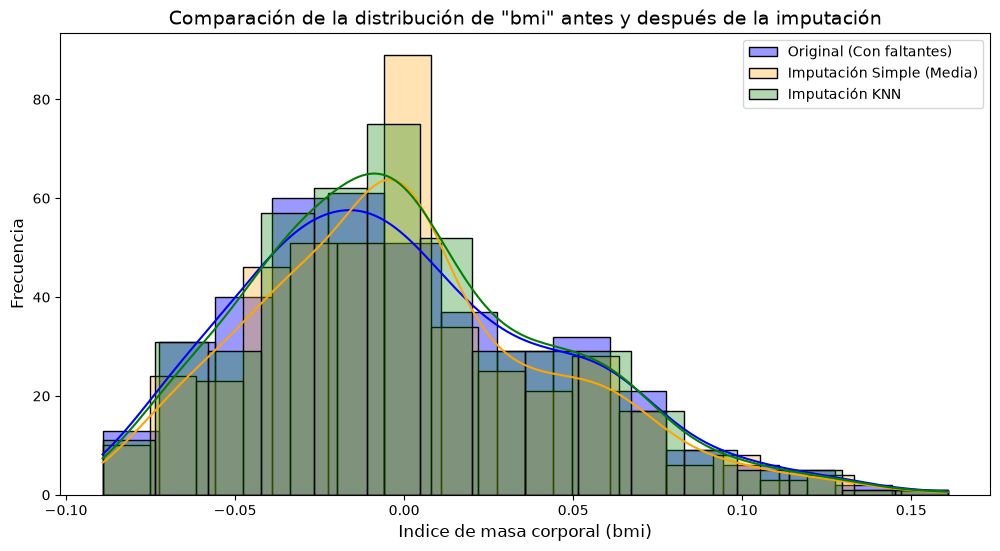

In [8]:
# Configura el tamaño de la gráfica
plt.figure(figsize=(12, 6))

# Grafica la distribución original (eliminando los NaN temporalmente para la gráfica
sns.histplot(data['bmi'].dropna(), color='blue', label='Original (Con faltantes)', kde=True, alpha=0.4)

# Grafica la distribución con imputación simple
sns.histplot(data_simple['bmi'], color='orange', label='Imputación Simple (Media)', kde=True, alpha=0.3)

# Grafica la distribución con imputación KNN
sns.histplot(data_knn['bmi'], color='green', label='Imputación KNN', kde=True, alpha=0.3)

# Personaliza los detalles de la gráfica
plt.title('Comparación de la distribución de "bmi" antes y después de la imputación', fontsize=14)
plt.xlabel('Indice de masa corporal (bmi)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()

# Muestra la gráfica en el notebook
plt.show()